# Data Inspection

In [1]:
import h5py as h5
import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go
import glob
plt.style.use('../../utils/dune.mplstyle')

import sys, os

# Path to repo root (two directories above notebook)
repo_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
sys.path.append(repo_root)

from utils.backtracking import get_charge_event_hits, hit_backtracker, get_ancestry # Now this works
from utils.my_ev_display import event_display

In [2]:
# Function for loading source-on data

def load_source_data(files_loc):
    E = []
    loc = []
    evtid = []

    for file in glob.iglob(files_loc):
        with h5.File(file, 'r') as f:
            # Filter out hits with negative energy (likley from noisy pixels) for now
            positive_hits = f['charge/calib_prompt_hits/data'][f['charge/calib_prompt_hits/data']['E']>0]
            E.extend(positive_hits['E'])
            loc.extend(np.column_stack([np.array(positive_hits['ts_pps']), np.array(positive_hits['x']), np.array(positive_hits['y']), np.array(positive_hits['z'])]))
            evt_ref_region = f['charge/events/ref/charge/calib_prompt_hits/ref_region']
            for index,i in enumerate(evt_ref_region):
                if i[0]==0 and i[1]==0:
                    pass
                else:
                    evtid.extend(index*np.ones(i[1]-i[0]))

            evtid = np.array(evtid)[f['charge/calib_prompt_hits/data']['E']>0]

    return np.array(E), np.array(loc), np.array(evtid)

In [5]:
# Load source-on data

source_on_data = '/global/cfs/cdirs/dune/www/data/2x2/nearline_run2/flowed_charge/ColdOperations/data/2025_Operations_Cold/source/AmBe_0411/packet-0060080-2025_11_04_09_46_37_CST.FLOW.hdf5'

E_data, loc_data, evtid_data = load_source_data(source_on_data)

In [13]:
# Select hits from only external triggers

def get_AmBe_data(files_loc):
    # Select only AmBe neutron triggers from data
    E = []
    loc = []
    evtid = []

    for file in glob.iglob(files_loc):
        with h5.File(file, 'r') as f:
            # Filter out hits with negative energy (likley from noisy pixels) for now
            #positive_hits = f['charge/calib_prompt_hits/data'][f['charge/calib_prompt_hits/data']['E']>0]
            hits_cache = f['charge/calib_prompt_hits/data']
            # Get hits from events with external triggers
            ext_trigids = f['charge/ext_trigs/data']['id'][f['charge/ext_trigs/data']['iogroup']==6]
            print(len(ext_trigids))
            trig_evt_ref_region = f['charge/events/ref/charge/ext_trigs/ref_region']
            ext_trig_evtids = []
            for index,i in enumerate(trig_evt_ref_region):
                if i[0]==0 and i[1]==0:
                    pass
                else:
                    if index in ext_trigids:
                        ext_trig_evtids.extend(index*np.ones(i[1]-i[0], dtype=int))
                    else:
                        pass

            evt_ref_region = f['charge/events/ref/charge/calib_prompt_hits/ref_region']
            hit_ids = []
            for index,i in enumerate(set(ext_trig_evtids)):
                if evt_ref_region[i][0]==0 and evt_ref_region[i][1]==0:
                    print(f'{i}ya')
                    pass
                else:
                    evtid.extend(index*np.ones(evt_ref_region[i][1]-evt_ref_region[i][0]))
                    hit_ids.extend(np.arange(evt_ref_region[i][0],evt_ref_region[i][1]))
            
            E = hits_cache['E'][hit_ids]
            loc = np.column_stack([np.array(hits_cache['ts_pps'])[hit_ids], np.array(hits_cache['x'])[hit_ids], np.array(hits_cache['y'])[hit_ids], np.array(hits_cache['z'])[hit_ids]])


    # Exclude negative hits and format the data
    E = np.array(E)
    E_final = E[E>0]
    evtid = np.array(evtid)[E>0]
    loc = np.array(loc)[E>0]

    return E_final, loc, evtid

In [5]:
source_on_data = '/global/cfs/cdirs/dune/www/data/2x2/nearline_run2/flowed_charge/ColdOperations/data/2025_Operations_Cold/source/AmBe_0411/packet-0060080-2025_11_04_09_46_37_CST.FLOW.hdf5'

E_data, loc_data, evtid_data = get_AmBe_data(source_on_data)

16683
21ya
86ya
91ya
108ya
113ya
114ya
115ya
153ya
163ya
182ya
207ya
210ya
228ya
242ya
252ya
262ya
268ya
284ya
310ya
332ya
343ya
361ya
366ya
367ya
393ya
408ya
414ya
421ya
445ya
452ya
461ya
464ya
468ya
506ya
549ya
557ya
565ya
584ya
591ya
597ya
635ya
645ya
677ya
691ya
737ya
782ya
815ya
827ya
829ya
867ya
883ya
887ya
903ya
912ya
943ya
951ya
960ya
961ya
991ya
993ya
1000ya
1013ya
1018ya
1023ya
1025ya
1035ya
1094ya
1101ya
1112ya
1113ya
1122ya
1164ya
1168ya
1194ya
1218ya
1227ya
1303ya
1311ya
1313ya
1321ya
1343ya
1370ya
1406ya
1413ya
1424ya
1429ya
1432ya
1433ya
1436ya
1437ya
1463ya
1469ya
1471ya
1479ya
1495ya
1511ya
1548ya
1554ya
1563ya
1570ya
1591ya
1606ya
1619ya
1640ya
1716ya
1717ya
1737ya
1752ya
1761ya
1762ya
1764ya
1771ya
1779ya
1789ya
1815ya
1840ya
1856ya
1863ya
1870ya
1880ya
1884ya
1901ya
1946ya
1953ya
1954ya
1990ya
2015ya
2021ya
2058ya
2079ya
2083ya
2117ya
2126ya
2183ya
2190ya
2213ya
2230ya
2263ya
2270ya
2278ya
2283ya
2300ya
2322ya
2334ya
2373ya
2378ya
2395ya
2397ya
2398ya
2402ya
2403ya


In [6]:
print(len(E_data))
print(len(evtid_data))
print(len(loc_data))
print(len(set(evtid_data)))

print(E_data[500])
print(evtid_data[500])
print(loc_data[500])

736157
736157
736157
14081
0.3002459630769495
9.0
[ 2.05529000e+05 -1.56330810e+01 -1.99807129e+01  5.93003387e+01]


In [7]:
for file in glob.iglob(source_on_data):
    with h5.File(file, 'r') as f:
        print(len(f['charge/calib_prompt_hits/data']))

991148


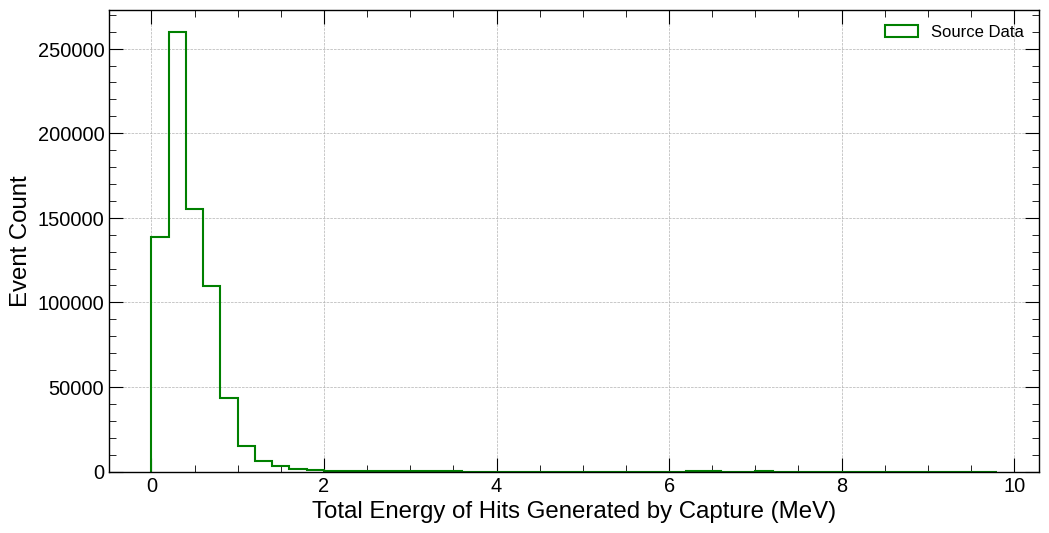

In [8]:
# Plot raw data energy histogram

plt.figure(figsize=(12, 6))

plt.hist(E_data, color='green', histtype='step', bins=np.arange(0,10,0.2), label='Source Data')

plt.xlabel('Total Energy of Hits Generated by Capture (MeV)')
plt.ylabel('Event Count')
plt.grid(True)
#plt.yscale('log')
#plt.ylim((0,10))
plt.legend()
plt.show()

In [70]:
def get_AmBe_data(files_loc):
    # Select only AmBe neutron triggers from data
    E = []
    loc = []
    evtid = []

    for file in glob.iglob(files_loc):
        with h5.File(file, 'r') as f:
            # Filter out hits with negative energy (likley from noisy pixels) for now
            #positive_hits = f['charge/calib_prompt_hits/data'][f['charge/calib_prompt_hits/data']['E']>0]
            hits_cache = f['charge/calib_prompt_hits/data']
            # Get hits from events with external triggers
            ext_trigids = f['charge/ext_trigs/data']['id'][(f['charge/ext_trigs/data']['iogroup']==5) | (f['charge/ext_trigs/data']['iogroup']==6)]
            trig_evt_ref_region = f['charge/events/ref/charge/ext_trigs/ref_region']
            ext_trig_evtids = []
            for index,i in enumerate(trig_evt_ref_region):
                if i[0]==0 and i[1]==0:
                    pass
                else:
                    if index in ext_trigids:
                        ext_trig_evtids.extend(index*np.ones(i[1]-i[0], dtype=int))
                    else:
                        pass

            evt_ref_region = f['charge/events/ref/charge/calib_prompt_hits/ref_region']
            hit_ids = []
            for index,i in enumerate(set(ext_trig_evtids)):
                if evt_ref_region[i][0]==0 and evt_ref_region[i][1]==0:
                    pass
                else:
                    evtid.extend(index*np.ones(evt_ref_region[i][1]-evt_ref_region[i][0]))
                    hit_ids.extend(np.arange(evt_ref_region[i][0],evt_ref_region[i][1]))
            
            E = hits_cache['E'][hit_ids]
            loc = np.column_stack([np.array(hits_cache['ts_pps'])[hit_ids], np.array(hits_cache['x'])[hit_ids], np.array(hits_cache['y'])[hit_ids], np.array(hits_cache['z'])[hit_ids]])

    # Exclude negative hits and format the data
    E = np.array(E)
    E_final = E[E>0]
    evtid = np.array(evtid)[E>0]
    loc = np.array(loc)[E>0]

    return E_final, loc, evtid

In [ ]:
# Load multiple datasets

AmBe_catwalk_E = []
AmBe_catwalk_loc = []
AmBe_catwalk_evtid = []

AmBe_catwalk_file = [file for file in glob.iglob('/global/cfs/cdirs/dune/www/data/2x2/nearline_run2/flowed_charge/ColdOperations/data/2025_Operations_Cold/source/AmBe_0311/*.hdf5')]

file_evtid = 0

for i in AmBe_catwalk_file:
    E_temp, loc_temp, evtid_temp = get_AmBe_data(i)
    AmBe_catwalk_E.extend(E_temp)
    AmBe_catwalk_loc.extend(loc_temp)
    AmBe_catwalk_evtid.extend(evtid_temp+file_evtid)
    file_evtid += max(evtid_temp)


In [ ]:
# Load data file
AmBe_E = []
AmBe_loc = []
AmBe_evtid = []

AmBe_file = [file for file in glob.iglob('/global/cfs/cdirs/dune/www/data/2x2/nearline_run2/flowed_charge/ColdOperations/data/2025_Operations_Cold/source/AmBe_0411_2/*.hdf5')]

file_evtid = 0

for i in AmBe_file:
    E_temp, loc_temp, evtid_temp = get_AmBe_data(i)
    AmBe_E.extend(E_temp)
    AmBe_loc.extend(loc_temp)
    AmBe_evtid.extend(evtid_temp+file_evtid)
    file_evtid += max(evtid_temp)

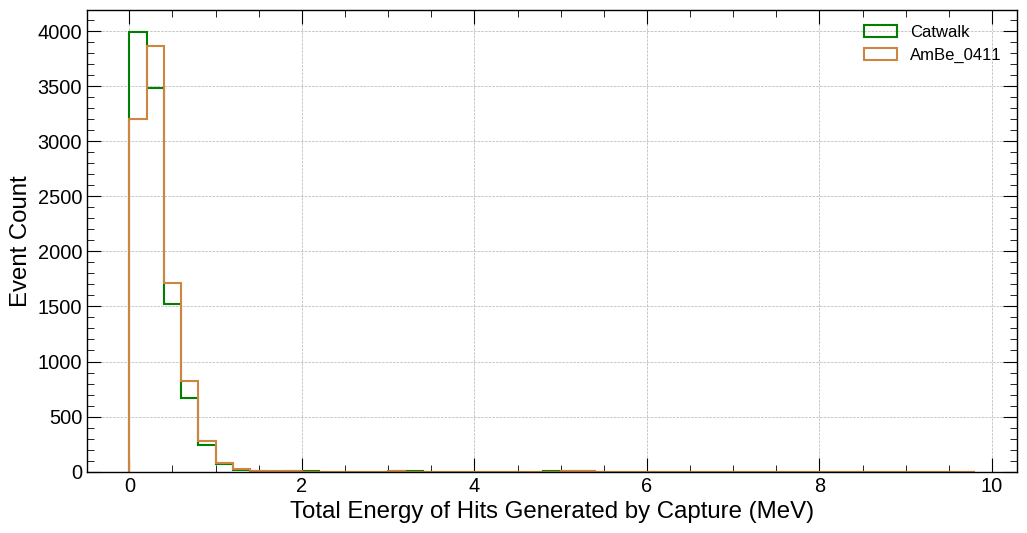

In [15]:
# Plot raw data energy histogram

plt.figure(figsize=(12, 6))

plt.hist(AmBe_catwalk_E[:10000], color='green', histtype='step', bins=np.arange(0,10,0.2), label='Catwalk')
plt.hist(AmBe_E[:10000], color='peru', histtype='step', bins=np.arange(0,10,0.2), label='AmBe_0411')

plt.xlabel('Total Energy of Hits Generated by Capture (MeV)')
plt.ylabel('Event Count')
plt.grid(True)
#plt.yscale('log')
#plt.ylim((0,10))
plt.legend()
plt.show()

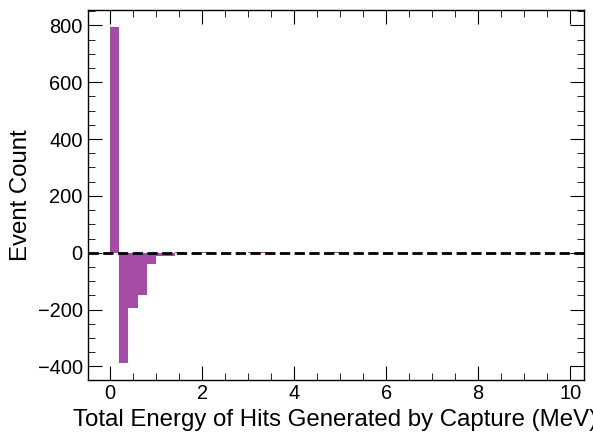

In [16]:
# Plot the difference
bins_range = np.arange(0,10,0.2)
counts1, _ = np.histogram(AmBe_catwalk_E[:10000], bins=bins_range)
counts2, _ = np.histogram(AmBe_E[:10000], bins=bins_range)

# 4. Calculate the difference
diff = counts1 - counts2

# 5. Plot the difference
plt.bar(bins_range[:-1], diff, width=np.diff(bins_range), align='edge', color='purple', alpha=0.7)
plt.xlabel('Total Energy of Hits Generated by Capture (MeV)')
plt.ylabel('Event Count')
plt.axhline(0, color='black', linestyle='--') # Add baseline
plt.show()

### Inspect all available data

In [4]:
from datetime import datetime

In [71]:
# Load data files

AmBe_0311_2_paths = [file for file in glob.iglob('/global/cfs/cdirs/dune/www/data/2x2/nearline_run2/flowed_charge/ColdOperations/data/2025_Operations_Cold/source/AmBe_0311_2/*.hdf5')]
AmBe_0311_2_file = sorted(AmBe_0311_2_paths, key=lambda x: datetime.strptime(x[139:158], '%Y_%m_%d_%H_%M_%S'))

AmBe_0411_2_paths = [file for file in glob.iglob('/global/cfs/cdirs/dune/www/data/2x2/nearline_run2/flowed_charge/ColdOperations/data/2025_Operations_Cold/source/AmBe_0411_2/*.hdf5')]
AmBe_0411_2_file = sorted(AmBe_0411_2_paths, key=lambda x: datetime.strptime(x[139:158], '%Y_%m_%d_%H_%M_%S'))

AmBe_1107_paths = [file for file in glob.iglob('/global/cfs/cdirs/dune/www/data/2x2/nearline_run2/flowed_charge/ColdOperations/data/2025_Operations_Cold/source/AmBe_1107/*.hdf5')]
AmBe_1107_file = sorted(AmBe_1107_paths, key=lambda x: datetime.strptime(x[137:156], '%Y_%m_%d_%H_%M_%S'))

AmBe_1111_2_paths = [file for file in glob.iglob('/global/cfs/cdirs/dune/www/data/2x2/nearline_run2/flowed_charge/ColdOperations/data/2025_Operations_Cold/source/AmBe_1111_2/*.hdf5')]
AmBe_1111_2_file = sorted(AmBe_1111_2_paths, key=lambda x: datetime.strptime(x[139:158], '%Y_%m_%d_%H_%M_%S'))

# Sort data files according to trigger settings

AmBe_catwalk_E = []
AmBe_catwalk_loc = []
AmBe_catwalk_evtid = []
AmBe_catwalk_file = [file for file in glob.iglob('/global/cfs/cdirs/dune/www/data/2x2/nearline_run2/flowed_charge/ColdOperations/data/2025_Operations_Cold/source/AmBe_0311/*.hdf5')]

AmBe_catwalk2_E = []
AmBe_catwalk2_loc = []
AmBe_catwalk2_evtid = []
AmBe_catwalk2_file = AmBe_0311_2_file[:4]

AmBe_0311_2_E = []
AmBe_0311_2_loc = []
AmBe_0311_2_evtid = []
AmBe_0311_2_file = AmBe_0311_2_file[4:]

AmBe_0311_3_E = []
AmBe_0311_3_loc = []
AmBe_0311_3_evtid = []
AmBe_0311_3_file = [file for file in glob.iglob('/global/cfs/cdirs/dune/www/data/2x2/nearline_run2/flowed_charge/ColdOperations/data/2025_Operations_Cold/source/AmBe_0311_3/*.hdf5')]

AmBe_0411_E = []
AmBe_0411_loc = []
AmBe_0411_evtid = []
AmBe_0411_file = [file for file in glob.iglob('/global/cfs/cdirs/dune/www/data/2x2/nearline_run2/flowed_charge/ColdOperations/data/2025_Operations_Cold/source/AmBe_0411/*.hdf5')]

AmBe_0411_1trig100per_E = []
AmBe_0411_1trig100per_loc = []
AmBe_0411_1trig100per_evtid = []
AmBe_0411_1trig100per_file = AmBe_0411_2_file[:33]

AmBe_0411_2trig80per_E = []
AmBe_0411_2trig80per_loc = []
AmBe_0411_2trig80per_evtid = []
AmBe_0411_2trig80per_file = AmBe_0411_2_file[33:]

# All AmBe_1107 files need to be checked according to Bruno
AmBe_1107_1count_E = []
AmBe_1107_1count_loc = []
AmBe_1107_1count_evtid = []
AmBe_1107_1count_file = AmBe_1107_file[:42]

AmBe_1107_2count80per_E = []
AmBe_1107_2count80per_loc = []
AmBe_1107_2count80per_evtid = []
AmBe_1107_2count80per_file = AmBe_1107_file[42:114]

AmBe_1107_2count128per_E = []
AmBe_1107_2count128per_loc = []
AmBe_1107_2count128per_evtid = []
AmBe_1107_2count128per_file = AmBe_1107_file[114:150]

AmBe_1107_2count176per_E = []
AmBe_1107_2count176per_loc = []
AmBe_1107_2count176per_evtid = []
AmBe_1107_2count176per_file = AmBe_1107_file[150:184]

AmBe_1107_2count224per_E = []
AmBe_1107_2count224per_loc = []
AmBe_1107_2count224per_evtid = []
AmBe_1107_2count224per_file = AmBe_1107_file[184:218]

AmBe_1107_2count272per_E = []
AmBe_1107_2count272per_loc = []
AmBe_1107_2count272per_evtid = []
AmBe_1107_2count272per_file = AmBe_1107_file[218:251]

AmBe_1107_2count32per_E = []
AmBe_1107_2count32per_loc = []
AmBe_1107_2count32per_evtid = []
AmBe_1107_2count32per_file = AmBe_1107_file[251:262]

AmBe_1107_2count109per_E = []
AmBe_1107_2count109per_loc = []
AmBe_1107_2count109per_evtid = []
AmBe_1107_2count109per_file = AmBe_1107_file[262:275]

AmBe_1107_2count147per_E = []
AmBe_1107_2count147per_loc = []
AmBe_1107_2count147per_evtid = []
AmBe_1107_2count147per_file = AmBe_1107_file[275:292]

AmBe_1107_2count320per_E = []
AmBe_1107_2count320per_loc = []
AmBe_1107_2count320per_evtid = []
AmBe_1107_2count320per_file = AmBe_1107_file[292:]

AmBe_nosource_E = []
AmBe_nosource_loc = []
AmBe_nosource_evtid = []
AmBe_nosource_file = [file for file in glob.iglob('/global/cfs/cdirs/dune/www/data/2x2/nearline_run2/flowed_charge/ColdOperations/data/2025_Operations_Cold/source/AmBe_noSource_2/*.hdf5')]

AmBe_1111_2count195per_E = []
AmBe_1111_2count195per_loc = []
AmBe_1111_2count195per_evtid = []
AmBe_1111_2count195per_file = [file for file in glob.iglob('/global/cfs/cdirs/dune/www/data/2x2/nearline_run2/flowed_charge/ColdOperations/data/2025_Operations_Cold/source/AmBe_1111/*.hdf5')]

AmBe_1111_2_2count243per_E = []
AmBe_1111_2_2count243per_loc = []
AmBe_1111_2_2count243per_evtid = []
AmBe_1111_2_2count243per_file = AmBe_1111_2_file[:18]

AmBe_1111_2_2count51per_E = []
AmBe_1111_2_2count51per_loc = []
AmBe_1111_2_2count51per_evtid = []
AmBe_1111_2_2count51per_file = AmBe_1111_2_file[18:35]

AmBe_1111_2_2count32per_E = []
AmBe_1111_2_2count32per_loc = []
AmBe_1111_2_2count32per_evtid = []
AmBe_1111_2_2count32per_file = []

AmBe_1111_2_2count291per_E = []
AmBe_1111_2_2count291per_loc = []
AmBe_1111_2_2count291per_evtid = []
AmBe_1111_2_2count291per_file = []


In [72]:
file_evtid = 0

for i in AmBe_catwalk_file:
    E_temp, loc_temp, evtid_temp = get_AmBe_data(i)
    AmBe_catwalk_E.extend(E_temp)
    AmBe_catwalk_loc.extend(loc_temp)
    AmBe_catwalk_evtid.extend(evtid_temp+file_evtid)
    file_evtid += max(evtid_temp)
    break

AmBe_catwalk_E = np.array(AmBe_catwalk_E)
AmBe_catwalk_loc = np.array(AmBe_catwalk_loc)
AmBe_catwalk_evtid = np.array(AmBe_catwalk_evtid)
AmBe_catwalk_event_E = np.array([sum(AmBe_catwalk_E[AmBe_catwalk_evtid==i]) for i in np.unique(AmBe_catwalk_evtid)])

In [73]:
file_evtid = 0

for i in AmBe_catwalk2_file:
    E_temp, loc_temp, evtid_temp = get_AmBe_data(i)
    AmBe_catwalk2_E.extend(E_temp)
    AmBe_catwalk2_loc.extend(loc_temp)
    AmBe_catwalk2_evtid.extend(evtid_temp+file_evtid)
    file_evtid += max(evtid_temp)
    break

AmBe_catwalk2_E = np.array(AmBe_catwalk2_E)
AmBe_catwalk2_loc = np.array(AmBe_catwalk2_loc)
AmBe_catwalk2_evtid = np.array(AmBe_catwalk2_evtid)
AmBe_catwalk2_event_E = np.array([sum(AmBe_catwalk2_E[AmBe_catwalk2_evtid==i]) for i in np.unique(AmBe_catwalk2_evtid)])

In [74]:
file_evtid = 0

for i in AmBe_0311_2_file:
    E_temp, loc_temp, evtid_temp = get_AmBe_data(i)
    AmBe_0311_2_E.extend(E_temp)
    AmBe_0311_2_loc.extend(loc_temp)
    AmBe_0311_2_evtid.extend(evtid_temp+file_evtid)
    file_evtid += max(evtid_temp)
    break

AmBe_0311_2_E = np.array(AmBe_0311_2_E)
AmBe_0311_2_loc = np.array(AmBe_0311_2_loc)
AmBe_0311_2_evtid = np.array(AmBe_0311_2_evtid)
AmBe_0311_2_event_E = np.array([sum(AmBe_0311_2_E[AmBe_0311_2_evtid==i]) for i in np.unique(AmBe_0311_2_evtid)])

In [75]:
file_evtid = 0

for i in AmBe_0311_3_file:
    E_temp, loc_temp, evtid_temp = get_AmBe_data(i)
    AmBe_0311_3_E.extend(E_temp)
    AmBe_0311_3_loc.extend(loc_temp)
    AmBe_0311_3_evtid.extend(evtid_temp+file_evtid)
    file_evtid += max(evtid_temp)
    break

AmBe_0311_3_E = np.array(AmBe_0311_3_E)
AmBe_0311_3_loc = np.array(AmBe_0311_3_loc)
AmBe_0311_3_evtid = np.array(AmBe_0311_3_evtid)
AmBe_0311_3_event_E = np.array([sum(AmBe_0311_3_E[AmBe_0311_3_evtid==i]) for i in np.unique(AmBe_0311_3_evtid)])

In [76]:
file_evtid = 0

for i in AmBe_0411_file:
    E_temp, loc_temp, evtid_temp = get_AmBe_data(i)
    AmBe_0411_E.extend(E_temp)
    AmBe_0411_loc.extend(loc_temp)
    AmBe_0411_evtid.extend(evtid_temp+file_evtid)
    file_evtid += max(evtid_temp)
    break

AmBe_0411_E = np.array(AmBe_0411_E)
AmBe_0411_loc = np.array(AmBe_0411_loc)
AmBe_0411_evtid = np.array(AmBe_0411_evtid)
AmBe_0411_event_E = np.array([sum(AmBe_0411_E[AmBe_0411_evtid==i]) for i in np.unique(AmBe_0411_evtid)])

In [77]:
file_evtid = 0

for i in AmBe_0411_1trig100per_file:
    E_temp, loc_temp, evtid_temp = get_AmBe_data(i)
    AmBe_0411_1trig100per_E.extend(E_temp)
    AmBe_0411_1trig100per_loc.extend(loc_temp)
    AmBe_0411_1trig100per_evtid.extend(evtid_temp+file_evtid)
    file_evtid += max(evtid_temp)
    break

AmBe_0411_1trig100per_E = np.array(AmBe_0411_1trig100per_E)
AmBe_0411_1trig100per_loc = np.array(AmBe_0411_1trig100per_loc)
AmBe_0411_1trig100per_evtid = np.array(AmBe_0411_1trig100per_evtid)
AmBe_0411_1trig100per_event_E = np.array([sum(AmBe_0411_1trig100per_E[AmBe_0411_1trig100per_evtid==i]) for i in np.unique(AmBe_0411_1trig100per_evtid)])

In [78]:
file_evtid = 0

for i in AmBe_0411_2trig80per_file:
    E_temp, loc_temp, evtid_temp = get_AmBe_data(i)
    AmBe_0411_2trig80per_E.extend(E_temp)
    AmBe_0411_2trig80per_loc.extend(loc_temp)
    AmBe_0411_2trig80per_evtid.extend(evtid_temp+file_evtid)
    file_evtid += max(evtid_temp)
    break

AmBe_0411_2trig80per_E = np.array(AmBe_0411_2trig80per_E)
AmBe_0411_2trig80per_loc = np.array(AmBe_0411_2trig80per_loc)
AmBe_0411_2trig80per_evtid = np.array(AmBe_0411_2trig80per_evtid)
AmBe_0411_2trig80per_event_E = np.array([sum(AmBe_0411_2trig80per_E[AmBe_0411_2trig80per_evtid==i]) for i in np.unique(AmBe_0411_2trig80per_evtid)])

In [79]:
file_evtid = 0

for i in AmBe_1107_1count_file:
    E_temp, loc_temp, evtid_temp = get_AmBe_data(i)
    AmBe_1107_1count_E.extend(E_temp)
    AmBe_1107_1count_loc.extend(loc_temp)
    AmBe_1107_1count_evtid.extend(evtid_temp+file_evtid)
    file_evtid += max(evtid_temp)
    break

AmBe_1107_1count_E = np.array(AmBe_1107_1count_E)
AmBe_1107_1count_loc = np.array(AmBe_1107_1count_loc)
AmBe_1107_1count_evtid = np.array(AmBe_1107_1count_evtid)
AmBe_1107_1count_event_E = np.array([sum(AmBe_1107_1count_E[AmBe_1107_1count_evtid==i]) for i in np.unique(AmBe_1107_1count_evtid)])

In [80]:
file_evtid = 0

for i in AmBe_1107_2count80per_file:
    E_temp, loc_temp, evtid_temp = get_AmBe_data(i)
    AmBe_1107_2count80per_E.extend(E_temp)
    AmBe_1107_2count80per_loc.extend(loc_temp)
    AmBe_1107_2count80per_evtid.extend(evtid_temp+file_evtid)
    file_evtid += max(evtid_temp)
    break

AmBe_1107_2count80per_E = np.array(AmBe_1107_2count80per_E)
AmBe_1107_2count80per_loc = np.array(AmBe_1107_2count80per_loc)
AmBe_1107_2count80per_evtid = np.array(AmBe_1107_2count80per_evtid)
AmBe_1107_2count80per_event_E = np.array([sum(AmBe_1107_2count80per_E[AmBe_1107_2count80per_evtid==i]) for i in np.unique(AmBe_1107_2count80per_evtid)])

In [81]:
file_evtid = 0

for i in AmBe_1107_2count128per_file:
    E_temp, loc_temp, evtid_temp = get_AmBe_data(i)
    AmBe_1107_2count128per_E.extend(E_temp)
    AmBe_1107_2count128per_loc.extend(loc_temp)
    AmBe_1107_2count128per_evtid.extend(evtid_temp+file_evtid)
    file_evtid += max(evtid_temp)
    break

AmBe_1107_2count128per_E = np.array(AmBe_1107_2count128per_E)
AmBe_1107_2count128per_loc = np.array(AmBe_1107_2count128per_loc)
AmBe_1107_2count128per_evtid = np.array(AmBe_1107_2count128per_evtid)
AmBe_1107_2count128per_event_E = np.array([sum(AmBe_1107_2count128per_E[AmBe_1107_2count128per_evtid==i]) for i in np.unique(AmBe_1107_2count128per_evtid)])

In [82]:
file_evtid = 0

for i in AmBe_1107_2count176per_file:
    E_temp, loc_temp, evtid_temp = get_AmBe_data(i)
    AmBe_1107_2count176per_E.extend(E_temp)
    AmBe_1107_2count176per_loc.extend(loc_temp)
    AmBe_1107_2count176per_evtid.extend(evtid_temp+file_evtid)
    file_evtid += max(evtid_temp)
    break

AmBe_1107_2count176per_E = np.array(AmBe_1107_2count176per_E)
AmBe_1107_2count176per_loc = np.array(AmBe_1107_2count176per_loc)
AmBe_1107_2count176per_evtid = np.array(AmBe_1107_2count176per_evtid)
AmBe_1107_2count176per_event_E = np.array([sum(AmBe_1107_2count176per_E[AmBe_1107_2count176per_evtid==i]) for i in np.unique(AmBe_1107_2count176per_evtid)])

In [83]:
file_evtid = 0

for i in AmBe_1107_2count224per_file:
    E_temp, loc_temp, evtid_temp = get_AmBe_data(i)
    AmBe_1107_2count224per_E.extend(E_temp)
    AmBe_1107_2count224per_loc.extend(loc_temp)
    AmBe_1107_2count224per_evtid.extend(evtid_temp+file_evtid)
    file_evtid += max(evtid_temp)
    break

AmBe_1107_2count224per_E = np.array(AmBe_1107_2count224per_E)
AmBe_1107_2count224per_loc = np.array(AmBe_1107_2count224per_loc)
AmBe_1107_2count224per_evtid = np.array(AmBe_1107_2count224per_evtid)
AmBe_1107_2count224per_event_E = np.array([sum(AmBe_1107_2count224per_E[AmBe_1107_2count224per_evtid==i]) for i in np.unique(AmBe_1107_2count224per_evtid)])

In [84]:
file_evtid = 0

for i in AmBe_1107_2count272per_file:
    E_temp, loc_temp, evtid_temp = get_AmBe_data(i)
    AmBe_1107_2count272per_E.extend(E_temp)
    AmBe_1107_2count272per_loc.extend(loc_temp)
    AmBe_1107_2count272per_evtid.extend(evtid_temp+file_evtid)
    file_evtid += max(evtid_temp)
    break

AmBe_1107_2count272per_E = np.array(AmBe_1107_2count272per_E)
AmBe_1107_2count272per_loc = np.array(AmBe_1107_2count272per_loc)
AmBe_1107_2count272per_evtid = np.array(AmBe_1107_2count272per_evtid)
AmBe_1107_2count272per_event_E = np.array([sum(AmBe_1107_2count272per_E[AmBe_1107_2count272per_evtid==i]) for i in np.unique(AmBe_1107_2count272per_evtid)])

In [85]:
file_evtid = 0

for i in AmBe_1107_2count32per_file:
    E_temp, loc_temp, evtid_temp = get_AmBe_data(i)
    AmBe_1107_2count32per_E.extend(E_temp)
    AmBe_1107_2count32per_loc.extend(loc_temp)
    AmBe_1107_2count32per_evtid.extend(evtid_temp+file_evtid)
    file_evtid += max(evtid_temp)
    break

AmBe_1107_2count32per_E = np.array(AmBe_1107_2count32per_E)
AmBe_1107_2count32per_loc = np.array(AmBe_1107_2count32per_loc)
AmBe_1107_2count32per_evtid = np.array(AmBe_1107_2count32per_evtid)
AmBe_1107_2count32per_event_E = np.array([sum(AmBe_1107_2count32per_E[AmBe_1107_2count32per_evtid==i]) for i in np.unique(AmBe_1107_2count32per_evtid)])

In [86]:
file_evtid = 0

for i in AmBe_1107_2count109per_file:
    E_temp, loc_temp, evtid_temp = get_AmBe_data(i)
    AmBe_1107_2count109per_E.extend(E_temp)
    AmBe_1107_2count109per_loc.extend(loc_temp)
    AmBe_1107_2count109per_evtid.extend(evtid_temp+file_evtid)
    file_evtid += max(evtid_temp)
    break

AmBe_1107_2count109per_E = np.array(AmBe_1107_2count109per_E)
AmBe_1107_2count109per_loc = np.array(AmBe_1107_2count109per_loc)
AmBe_1107_2count109per_evtid = np.array(AmBe_1107_2count109per_evtid)
AmBe_1107_2count109per_event_E = np.array([sum(AmBe_1107_2count109per_E[AmBe_1107_2count109per_evtid==i]) for i in np.unique(AmBe_1107_2count109per_evtid)])

In [87]:
file_evtid = 0

for i in AmBe_1107_2count147per_file:
    E_temp, loc_temp, evtid_temp = get_AmBe_data(i)
    AmBe_1107_2count147per_E.extend(E_temp)
    AmBe_1107_2count147per_loc.extend(loc_temp)
    AmBe_1107_2count147per_evtid.extend(evtid_temp+file_evtid)
    file_evtid += max(evtid_temp)
    break

AmBe_1107_2count147per_E = np.array(AmBe_1107_2count147per_E)
AmBe_1107_2count147per_loc = np.array(AmBe_1107_2count147per_loc)
AmBe_1107_2count147per_evtid = np.array(AmBe_1107_2count147per_evtid)
AmBe_1107_2count147per_event_E = np.array([sum(AmBe_1107_2count147per_E[AmBe_1107_2count147per_evtid==i]) for i in np.unique(AmBe_1107_2count147per_evtid)])

In [88]:
file_evtid = 0

for i in AmBe_1107_2count320per_file:
    E_temp, loc_temp, evtid_temp = get_AmBe_data(i)
    AmBe_1107_2count320per_E.extend(E_temp)
    AmBe_1107_2count320per_loc.extend(loc_temp)
    AmBe_1107_2count320per_evtid.extend(evtid_temp+file_evtid)
    file_evtid += max(evtid_temp)
    break

AmBe_1107_2count320per_E = np.array(AmBe_1107_2count320per_E)
AmBe_1107_2count320per_loc = np.array(AmBe_1107_2count320per_loc)
AmBe_1107_2count320per_evtid = np.array(AmBe_1107_2count320per_evtid)
AmBe_1107_2count320per_event_E = np.array([sum(AmBe_1107_2count320per_E[AmBe_1107_2count320per_evtid==i]) for i in np.unique(AmBe_1107_2count320per_evtid)])

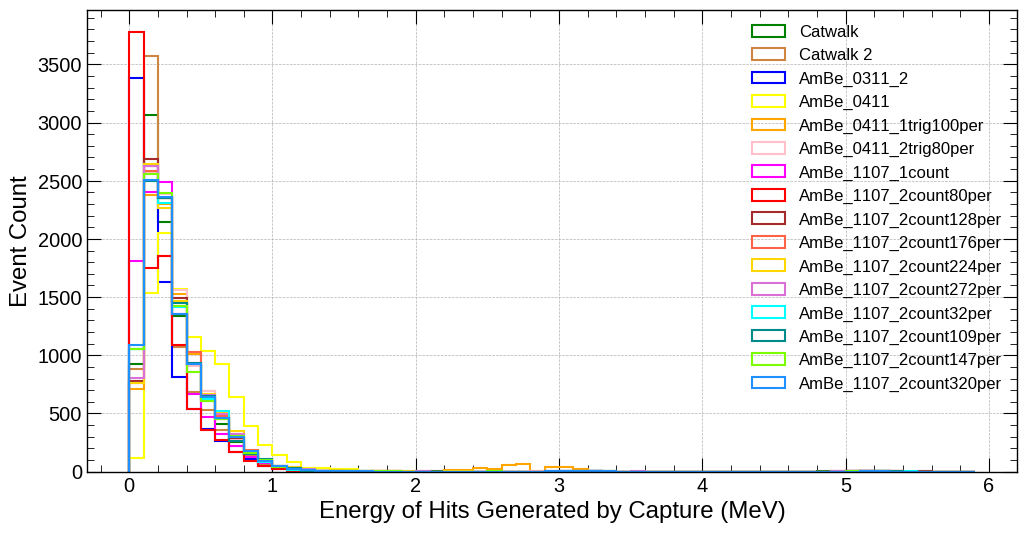

In [89]:
# Plot raw data energy histogram

plt.figure(figsize=(12, 6))

plt.hist(AmBe_catwalk_E[:10000], color='green', histtype='step', bins=np.arange(0,6,0.1), label='Catwalk')
plt.hist(AmBe_catwalk2_E[:10000], color='peru', histtype='step', bins=np.arange(0,6,0.1), label='Catwalk 2')
plt.hist(AmBe_0311_2_E[:10000], color='blue', histtype='step', bins=np.arange(0,6,0.1), label='AmBe_0311_2')
plt.hist(AmBe_0411_E[:10000], color='yellow', histtype='step', bins=np.arange(0,6,0.1), label='AmBe_0411')
plt.hist(AmBe_0411_1trig100per_E[:10000], color='orange', histtype='step', bins=np.arange(0,6,0.1), label='AmBe_0411_1trig100per')
plt.hist(AmBe_0411_2trig80per_E[:10000], color='pink', histtype='step', bins=np.arange(0,6,0.1), label='AmBe_0411_2trig80per')
plt.hist(AmBe_1107_1count_E[:10000], color='magenta', histtype='step', bins=np.arange(0,6,0.1), label='AmBe_1107_1count')
plt.hist(AmBe_1107_2count80per_E[:10000], color='red', histtype='step', bins=np.arange(0,6,0.1), label='AmBe_1107_2count80per')
plt.hist(AmBe_1107_2count128per_E[:10000], color='brown', histtype='step', bins=np.arange(0,6,0.1), label='AmBe_1107_2count128per')
plt.hist(AmBe_1107_2count176per_E[:10000], color='tomato', histtype='step', bins=np.arange(0,6,0.1), label='AmBe_1107_2count176per')
plt.hist(AmBe_1107_2count224per_E[:10000], color='gold', histtype='step', bins=np.arange(0,6,0.1), label='AmBe_1107_2count224per')
plt.hist(AmBe_1107_2count272per_E[:10000], color='orchid', histtype='step', bins=np.arange(0,6,0.1), label='AmBe_1107_2count272per')
plt.hist(AmBe_1107_2count32per_E[:10000], color='cyan', histtype='step', bins=np.arange(0,6,0.1), label='AmBe_1107_2count32per')
plt.hist(AmBe_1107_2count109per_E[:10000], color='darkcyan', histtype='step', bins=np.arange(0,6,0.1), label='AmBe_1107_2count109per')
plt.hist(AmBe_1107_2count147per_E[:10000], color='lawngreen', histtype='step', bins=np.arange(0,6,0.1), label='AmBe_1107_2count147per')
plt.hist(AmBe_1107_2count320per_E[:10000], color='dodgerblue', histtype='step', bins=np.arange(0,6,0.1), label='AmBe_1107_2count320per')


plt.xlabel('Energy of Hits Generated by Capture (MeV)')
plt.ylabel('Event Count')
plt.grid(True)
#plt.yscale('log')
#plt.ylim((0,10))
plt.legend()
plt.show()

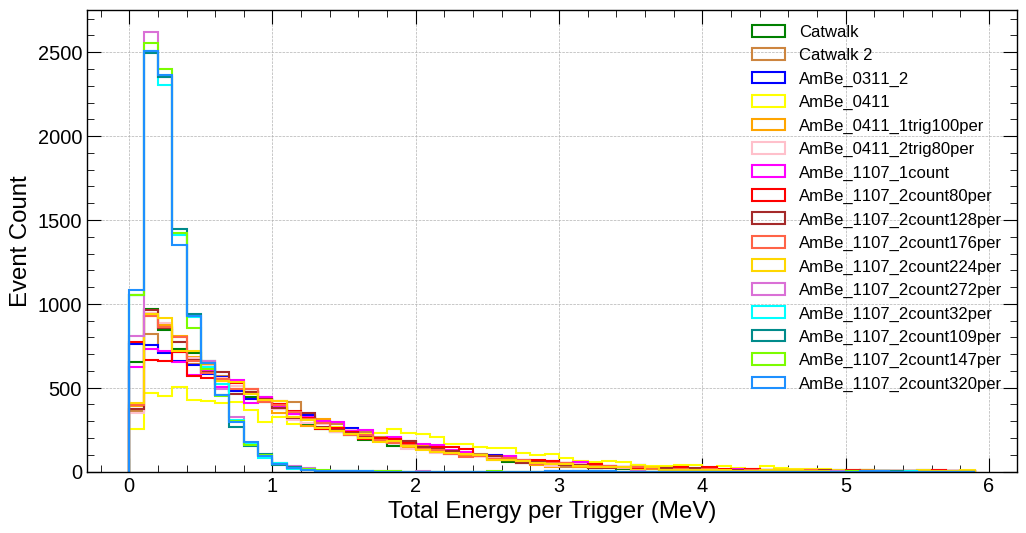

In [104]:
# Plot raw data energy histogram

plt.figure(figsize=(12, 6))

plt.hist(AmBe_catwalk_event_E[:10000], color='green', histtype='step', bins=np.arange(0,6,0.1), label='Catwalk')
plt.hist(AmBe_catwalk2_event_E[:10000], color='peru', histtype='step', bins=np.arange(0,6,0.1), label='Catwalk 2')
plt.hist(AmBe_0311_2_event_E[:10000], color='blue', histtype='step', bins=np.arange(0,6,0.1), label='AmBe_0311_2')
plt.hist(AmBe_0411_event_E[:10000], color='yellow', histtype='step', bins=np.arange(0,6,0.1), label='AmBe_0411')
plt.hist(AmBe_0411_1trig100per_event_E[:10000], color='orange', histtype='step', bins=np.arange(0,6,0.1), label='AmBe_0411_1trig100per')
plt.hist(AmBe_0411_2trig80per_event_E[:10000], color='pink', histtype='step', bins=np.arange(0,6,0.1), label='AmBe_0411_2trig80per')
plt.hist(AmBe_1107_1count_event_E[:10000], color='magenta', histtype='step', bins=np.arange(0,6,0.1), label='AmBe_1107_1count')
plt.hist(AmBe_1107_2count80per_event_E[:10000], color='red', histtype='step', bins=np.arange(0,6,0.1), label='AmBe_1107_2count80per')
plt.hist(AmBe_1107_2count128per_event_E[:10000], color='brown', histtype='step', bins=np.arange(0,6,0.1), label='AmBe_1107_2count128per')
plt.hist(AmBe_1107_2count176per_event_E[:10000], color='tomato', histtype='step', bins=np.arange(0,6,0.1), label='AmBe_1107_2count176per')
plt.hist(AmBe_1107_2count224per_event_E[:10000], color='gold', histtype='step', bins=np.arange(0,6,0.1), label='AmBe_1107_2count224per')
plt.hist(AmBe_1107_2count272per_E[:10000], color='orchid', histtype='step', bins=np.arange(0,6,0.1), label='AmBe_1107_2count272per')
plt.hist(AmBe_1107_2count32per_E[:10000], color='cyan', histtype='step', bins=np.arange(0,6,0.1), label='AmBe_1107_2count32per')
plt.hist(AmBe_1107_2count109per_E[:10000], color='darkcyan', histtype='step', bins=np.arange(0,6,0.1), label='AmBe_1107_2count109per')
plt.hist(AmBe_1107_2count147per_E[:10000], color='lawngreen', histtype='step', bins=np.arange(0,6,0.1), label='AmBe_1107_2count147per')
plt.hist(AmBe_1107_2count320per_E[:10000], color='dodgerblue', histtype='step', bins=np.arange(0,6,0.1), label='AmBe_1107_2count320per')


plt.xlabel('Total Energy per Trigger (MeV)')
plt.ylabel('Event Count')
plt.grid(True)
#plt.yscale('log')
#plt.ylim((0,10))
plt.legend()
plt.show()

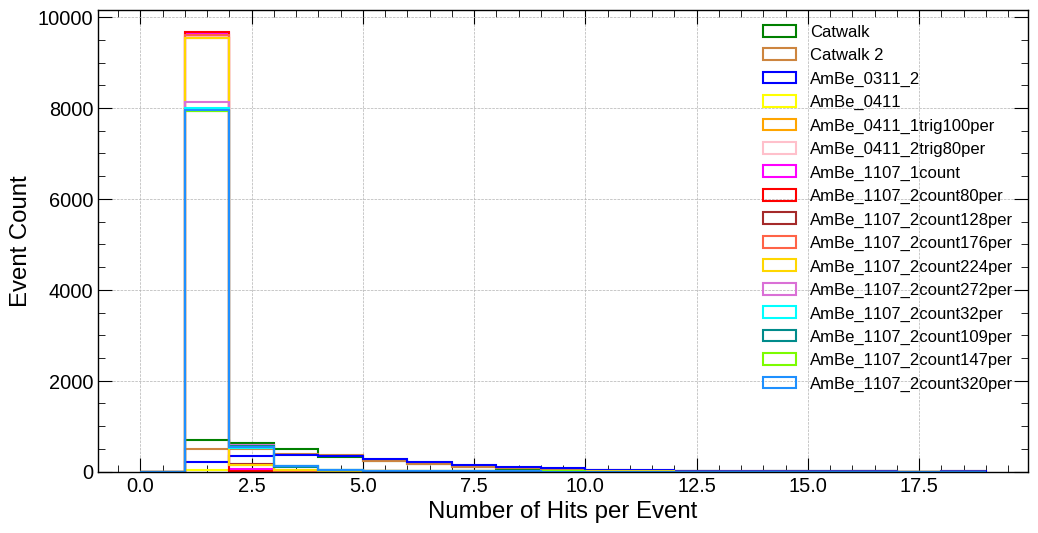

In [106]:
# Number of hits per event

plt.figure(figsize=(12, 6))

plt.hist(np.unique(AmBe_catwalk_evtid[:10000], return_counts=True)[1], color='green', histtype='step', bins=np.arange(0,20,1), label='Catwalk')
plt.hist(np.unique(AmBe_catwalk2_evtid[:10000], return_counts=True)[1], color='peru', histtype='step', bins=np.arange(0,20,1), label='Catwalk 2')
plt.hist(np.unique(AmBe_0311_2_evtid[:10000], return_counts=True)[1], color='blue', histtype='step', bins=np.arange(0,20,1), label='AmBe_0311_2')
plt.hist(np.unique(AmBe_0411_evtid[:10000], return_counts=True)[1], color='yellow', histtype='step', bins=np.arange(0,20,1), label='AmBe_0411')
plt.hist(np.unique(AmBe_0411_1trig100per_event_E[:10000], return_counts=True)[1], color='orange', histtype='step', bins=np.arange(0,20,1), label='AmBe_0411_1trig100per')
plt.hist(np.unique(AmBe_0411_2trig80per_event_E[:10000], return_counts=True)[1], color='pink', histtype='step', bins=np.arange(0,20,1), label='AmBe_0411_2trig80per')
plt.hist(np.unique(AmBe_1107_1count_event_E[:10000], return_counts=True)[1], color='magenta', histtype='step', bins=np.arange(0,20,1), label='AmBe_1107_1count')
plt.hist(np.unique(AmBe_1107_2count80per_event_E[:10000], return_counts=True)[1], color='red', histtype='step', bins=np.arange(0,20,1), label='AmBe_1107_2count80per')
plt.hist(np.unique(AmBe_1107_2count128per_event_E[:10000], return_counts=True)[1], color='brown', histtype='step', bins=np.arange(0,20,1), label='AmBe_1107_2count128per')
plt.hist(np.unique(AmBe_1107_2count176per_event_E[:10000], return_counts=True)[1], color='tomato', histtype='step', bins=np.arange(0,20,1), label='AmBe_1107_2count176per')
plt.hist(np.unique(AmBe_1107_2count224per_event_E[:10000], return_counts=True)[1], color='gold', histtype='step', bins=np.arange(0,20,1), label='AmBe_1107_2count224per')
plt.hist(np.unique(AmBe_1107_2count272per_E[:10000], return_counts=True)[1], color='orchid', histtype='step', bins=np.arange(0,20,1), label='AmBe_1107_2count272per')
plt.hist(np.unique(AmBe_1107_2count32per_E[:10000], return_counts=True)[1], color='cyan', histtype='step', bins=np.arange(0,20,1), label='AmBe_1107_2count32per')
plt.hist(np.unique(AmBe_1107_2count109per_E[:10000], return_counts=True)[1], color='darkcyan', histtype='step', bins=np.arange(0,20,1), label='AmBe_1107_2count109per')
plt.hist(np.unique(AmBe_1107_2count147per_E[:10000], return_counts=True)[1], color='lawngreen', histtype='step', bins=np.arange(0,20,1), label='AmBe_1107_2count147per')
plt.hist(np.unique(AmBe_1107_2count320per_E[:10000], return_counts=True)[1], color='dodgerblue', histtype='step', bins=np.arange(0,20,1), label='AmBe_1107_2count320per')


plt.xlabel('Number of Hits per Event')
plt.ylabel('Event Count')
plt.grid(True)
#plt.yscale('log')
#plt.ylim((0,2000))
plt.legend()
plt.show()

In [ ]:
# Apply DBScan on all data

